In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

ratings = pd.read_csv('../data/ratings.csv')
books = pd.read_csv('../data/books.csv')

user_counts = ratings['user_id'].value_counts()
active_users = user_counts[user_counts>=5].index
ratings = ratings[ratings['user_id'].isin(active_users)]

user_ids = ratings['user_id'].unique()
book_ids = ratings['book_id'].unique()
user2idx = {user_id: idx for idx, user_id in enumerate(user_ids)}
book2idx = {book_id: idx for idx, book_id in enumerate(book_ids)}
ratings['user_idx'] = ratings['user_id'].map(user2idx)
ratings['book_idx'] = ratings['book_id'].map(book2idx)

n_users = len(user2idx)
n_books = len(book2idx)

train_data, test_data = train_test_split(ratings, test_size=0.2, random_state=42)

print(f"Users: {n_users:,} | Books: {n_books:,}")
print(f"Train: {len(train_data):,} | Test: {len(test_data):,}")
print(f"PyTorch: {torch.__version__}")

Users: 35,710 | Books: 10,000
Train: 746,352 | Test: 186,588
PyTorch: 2.12.0+cpu


In [3]:
class RatingsDataset(Dataset):
    def __init__(self,df):
        self.users = torch.tensor(df['user_idx'].values, dtype = torch.long)
        self.books = torch.tensor(df['book_idx'].values, dtype = torch.long)
        self.ratings = torch.tensor(df['rating'].values, dtype = torch.float32)

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return self.users[idx], self.books[idx], self.ratings[idx]

train_dataset = RatingsDataset(train_data)
test_dataset = RatingsDataset(test_data)

train_loader = DataLoader(train_dataset, batch_size=1024, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size=1024, shuffle = False)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 729
Test batches: 183


In [5]:
class NCF(nn.Module):
    def __init__(self, n_users, n_books, embedding_dim=50, hidden_layers=[128,64,32], dropout=0.2):
        super().__init__()

        self.user_embeddings = nn.Embedding(n_users, embedding_dim)
        self.book_embeddings = nn.Embedding(n_books, embedding_dim)

        nn.init.normal_(self.user_embeddings.weight, std=0.01)
        nn.init.normal_(self.book_embeddings.weight, std=0.01)

        nn.init.normal_(self.user_embeddings.weight, std=0.01)
        nn.init.normal_(self.book_embeddings.weight, std=0.01)

        layers=[]
        input_dim = embedding_dim*2

        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(input_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            input_dim = hidden_dim

        layers.append(nn.Linear(input_dim,1))
        self.network = nn.Sequential(*layers)

    def forward(self, user_idx, book_idx):
        user_emb = self.user_embeddings(user_idx)
        book_emb = self.book_embeddings(book_idx)
        concat = torch.cat([user_emb, book_emb], dim=1)
        output = self.network(concat)
        return output.squeeze()

model = NCF(n_users, n_books, embedding_dim=50, hidden_layers=[128,64,32], dropout=0.2)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

NCF(
  (user_embeddings): Embedding(35710, 50)
  (book_embeddings): Embedding(10000, 50)
  (network): Sequential(
    (0): Linear(in_features=100, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total parameters: 2,308,797


In [9]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss=0
    for user_idx, book_idx, rating in loader:
        optimizer.zero_grad()
        prediction = model(user_idx, book_idx)
        loss = criterion(prediction, rating)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for user_idx, book_idx, rating in loader:
            prediction = model(user_idx, book_idx)
            loss = criterion(prediction, rating)
            total_loss += loss.item()
        return total_loss / len(loader)

n_epochs = 20
patience = 3
best_test_loss = float('inf')
epochs_without_improvement = 0
train_losses, test_losses = [],[]
best_model_state = None

for epoch in range(n_epochs):
    train_loss = train_epoch(model, train_loader, optimizer, criterion)
    test_loss = evaluate(model, test_loader, criterion)

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    if test_loss < best_test_loss:
        best_test_loss = test_loss
        best_model_state = model.state_dict().copy()
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
    print(f"Epoch{epoch+1:02d}/{n_epochs}| Train: {train_loss:.4f} |Test: {test_loss:.4f} | Best: {best_test_loss:.4f} {'*' if epochs_without_improvement == 0 else ''} ")

    if epochs_without_improvement >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        break

model.load_state_dict(best_model_state)
print(f"\nBest test loss: {best_test_loss:.4f}")


Epoch01/20| Train: 1.9050 |Test: 0.7304 | Best: 0.7304 * 
Epoch02/20| Train: 0.9325 |Test: 0.7095 | Best: 0.7095 * 
Epoch03/20| Train: 0.8584 |Test: 0.6996 | Best: 0.6996 * 
Epoch04/20| Train: 0.8123 |Test: 0.7006 | Best: 0.6996  
Epoch05/20| Train: 0.7723 |Test: 0.7000 | Best: 0.6996  
Epoch06/20| Train: 0.7342 |Test: 0.7044 | Best: 0.6996  

Early stopping triggered at epoch 6

Best test loss: 0.6996


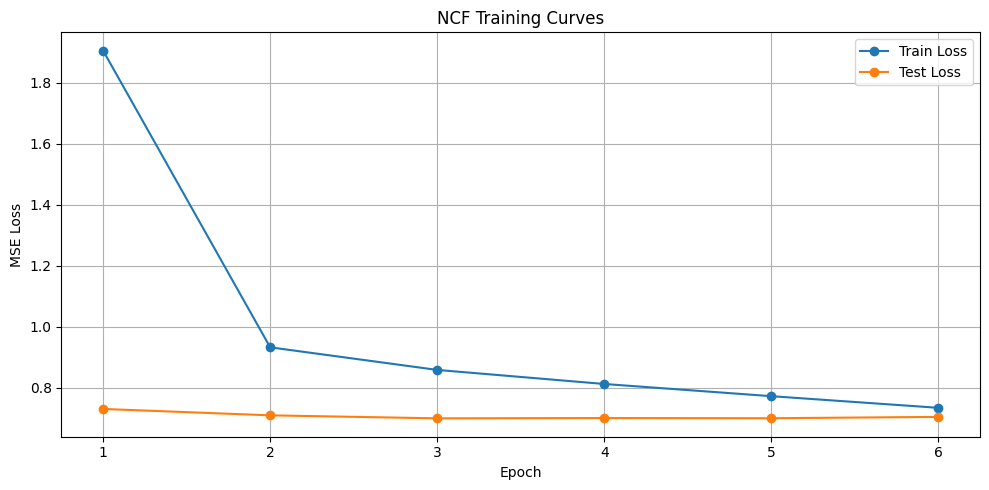

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_losses)+1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, len(test_losses)+1), test_losses, label='Test Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('NCF Training Curves')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [11]:
import os

torch.save({
    'model_state_dict': best_model_state,
    'user2idx': user2idx,
    'book2idx': book2idx,
    'n_users': n_users,
    'n_books': n_books,
    'embedding_dim': 50,
    'hidden_layers': [128, 64, 32],
    'dropout': 0.2,
    'best_test_loss': best_test_loss,
    'train_losses': train_losses,
    'test_losses': test_losses,
}, '../models/ncf_model.pt')

print("Model saved to ../models/ncf_model.pt")
print(f"File size: {os.path.getsize('../models/ncf_model.pt') / 1024 / 1024:.1f} MB")

Model saved to ../models/ncf_model.pt
File size: 11.2 MB


# Neural Collaborative Filtering Summary

## Model Architecture
- User embeddings: 35,710 × 50
- Book embeddings: 10,000 × 50
- Concat (100d) → Linear(128) → ReLU → Dropout(0.2)
- → Linear(64) → ReLU → Dropout(0.2)
- → Linear(32) → ReLU → Dropout(0.2)
- → Linear(1)
- Total parameters: 2,308,797

## Training
- Optimiser: Adam (lr=0.001)
- Loss: MSE
- Max epochs: 20, batch size: 1024
- Early stopping patience: 3
- Stopped at epoch 6, best at epoch 3

## Results vs All Baselines
| Model | RMSE |
|---|---|
| Item-Item CF | 0.9069 |
| Matrix Factorisation | ~0.832 |
| NCF | ~0.836 |

## Key Learnings
- Early stopping prevented overfitting automatically
- Dropout inflates train loss — test loss is better signal
- NCF matched MF closely — consistent with Rendle et al. 2020
- Non-linear layers didn't dramatically improve over dot product here
- Cold start still unsolved — next notebook adds MiniLM embeddings

## Next Step
- 05_hybrid_model.ipynb
- Add MiniLM book description embeddings for cold start handling